In [12]:
import earthkit
import earthkit.plots
import earthkit.geo.cartography

countries = ["Germany", "United Kingdom", "Italy"] # List of countries

shapes = earthkit.geo.cartography.country_polygons(countries, resolution=50e6)

request = { "class": "od", "stream" : "oper", "type" : "fc", "levtype" : "sfc",
    "date" : 0,
    "time" : 0,
    "expver" : 1,
    "param" : [ 167, 151 ],
    "step": 0,
    "feature": {
        "type": "polygon",
        "shape": shapes,
    },
}

ds = earthkit.data.from_source("polytope", "ecmwf-mars", request, stream=False, address='polytope.ecmwf.int').to_xarray()

2026-02-27 12:05:36 - INFO - Key read from /Users/mavj/.polytopeapirc
2026-02-27 12:05:36 - INFO - Sending request...
{'request': 'class: od\n'
            'date: 0\n'
            'expver: 1\n'
            'feature:\n'
            '  shape:\n'
            '  - - - 53.172412109374996\n'
            '      - -4.278613281249989\n'
            '    - - 53.1341796875\n'
            '      - -4.373046875\n'
            '    - - 53.178027343749996\n'
            '      - -4.418847656249994\n'
            '    - - 53.1763671875\n'
            '      - -4.471972656249989\n'
            '    - - 53.26044921875\n'
            '      - -4.55322265625\n'
            '    - - 53.386474609375\n'
            '      - -4.56787109375\n'
            '    - - 53.419287109375\n'
            '      - -4.461718749999989\n'
            '    - - 53.417236328125\n'
            '      - -4.315087890624994\n'
            '    - - 53.321435546875\n'
            '      - -4.19677734375\n'
            '    - - 53.30

2026-02-27 12:05:36 - INFO - Polytope user key found in session cache for user mavj
2026-02-27 12:05:41 - INFO - Request accepted. Please poll ./e0f255c4-952c-4bc1-8c75-ee66ba3c6353 for status
2026-02-27 12:05:41 - INFO - Polytope user key found in session cache for user mavj
2026-02-27 12:05:41 - INFO - Checking request status (e0f255c4-952c-4bc1-8c75-ee66ba3c6353)...
2026-02-27 12:05:41 - INFO - The current status of the request is 'queued'
2026-02-27 12:05:42 - INFO - The current status of the request is 'processing'
2026-02-27 12:05:57 - INFO - The current status of the request is 'processed'


In [13]:
ds

<xarray.Dataset> Size: 494kB
Dimensions:    (datetimes: 1, number: 1, steps: 1, points: 10286)
Coordinates:
  * datetimes  (datetimes) <U20 80B '2026-02-27T00:00:00Z'
  * number     (number) int64 8B 0
  * steps      (steps) int64 8B 0
  * points     (points) int64 82kB 0 1 2 3 4 5 ... 10281 10282 10283 10284 10285
    latitude   (points) float64 82kB 36.73 36.73 36.73 36.8 ... 60.7 60.7 60.77
    longitude  (points) float64 82kB 14.76 14.88 15.0 ... 358.9 359.1 359.1
    levelist   (points) float64 82kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables:
    msl        (datetimes, number, steps, points) float64 82kB 1.028e+05 ... ...
    2t         (datetimes, number, steps, points) float64 82kB 283.7 ... 280.1
Attributes:
    class:          od
    Forecast date:  2026-02-27T00:00:00Z
    domain:         g
    expver:         0001
    levtype:        sfc
    step:           0
    stream:         oper
    type:           fc
    number:         0
    date:           2026-02-27T00:00:00Z

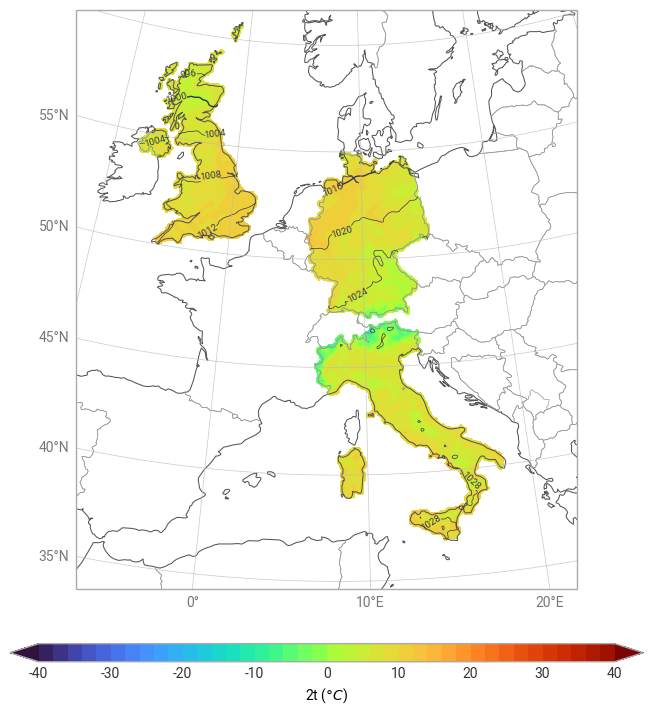

In [18]:
chart = earthkit.plots.Map(domain=countries)
chart.contourf(ds["2t"], units="celsius", style="auto")
chart.contour(ds["msl"], units="hPa", style="auto")
chart.coastlines()
chart.borders()
chart.gridlines()
chart.legend()
chart.show()
